In [1]:
import tensorflow as tf
print("Num GPUs Available: ", len(tf.config.list_physical_devices('GPU')))
gpus = tf.config.list_physical_devices('GPU')
if gpus:
  try:
    # Currently, memory growth needs to be the same across GPUs
    for gpu in gpus:
      tf.config.experimental.set_memory_growth(gpu, True)
    logical_gpus = tf.config.list_logical_devices('GPU')
    print(len(gpus), "Physical GPUs,", len(logical_gpus), "Logical GPUs")
  except RuntimeError as e:
    # Memory growth must be set before GPUs have been initialized
    print(e)



2023-03-28 11:47:44.902377: I tensorflow/core/platform/cpu_feature_guard.cc:193] This TensorFlow binary is optimized with oneAPI Deep Neural Network Library (oneDNN) to use the following CPU instructions in performance-critical operations:  AVX2 FMA
To enable them in other operations, rebuild TensorFlow with the appropriate compiler flags.
2023-03-28 11:47:45.373033: W tensorflow/compiler/xla/stream_executor/platform/default/dso_loader.cc:64] Could not load dynamic library 'libnvinfer.so.7'; dlerror: libnvinfer.so.7: cannot open shared object file: No such file or directory; LD_LIBRARY_PATH: :/home/xmatyas/miniconda3/envs/tf_gpu/lib/
2023-03-28 11:47:45.373076: W tensorflow/compiler/xla/stream_executor/platform/default/dso_loader.cc:64] Could not load dynamic library 'libnvinfer_plugin.so.7'; dlerror: libnvinfer_plugin.so.7: cannot open shared object file: No such file or directory; LD_LIBRARY_PATH: :/home/xmatyas/miniconda3/envs/tf_gpu/lib/
2023-03-28 11:47:45.373081: W tensorflow/com

Num GPUs Available:  1
1 Physical GPUs, 1 Logical GPUs


2023-03-28 11:47:45.930775: I tensorflow/compiler/xla/stream_executor/cuda/cuda_gpu_executor.cc:981] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero
2023-03-28 11:47:45.934799: I tensorflow/compiler/xla/stream_executor/cuda/cuda_gpu_executor.cc:981] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero
2023-03-28 11:47:45.934935: I tensorflow/compiler/xla/stream_executor/cuda/cuda_gpu_executor.cc:981] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero
2023-03-28 11:47:45.935452: I tensorflow/core/platform/cpu_feature_guard.cc:193] This TensorFlow binary is optimized with oneAPI Deep Neural Network Library (oneDNN) to use the following CPU instructions in performance-critical operations:  AVX2 FMA
To enable them in other operations, rebuild TensorF

In [2]:
#
# This is a sample Notebook to demonstrate how to read "MNIST Dataset"
#
import numpy as np # linear algebra
import struct
from array import array
from os.path  import join

#
# MNIST Data Loader Class
#
class MnistDataloader(object):
    def __init__(self, training_images_filepath,training_labels_filepath,
                 test_images_filepath, test_labels_filepath):
        self.training_images_filepath = training_images_filepath
        self.training_labels_filepath = training_labels_filepath
        self.test_images_filepath = test_images_filepath
        self.test_labels_filepath = test_labels_filepath
    
    def read_images_labels(self, images_filepath, labels_filepath):        
        labels = []
        with open(labels_filepath, 'rb') as file:
            magic, size = struct.unpack(">II", file.read(8))
            if magic != 2049:
                raise ValueError('Magic number mismatch, expected 2049, got {}'.format(magic))
            labels = array("B", file.read())        
        
        with open(images_filepath, 'rb') as file:
            magic, size, rows, cols = struct.unpack(">IIII", file.read(16))
            if magic != 2051:
                raise ValueError('Magic number mismatch, expected 2051, got {}'.format(magic))
            image_data = array("B", file.read())        
        images = []
        for i in range(size):
            images.append([0] * rows * cols)
        for i in range(size):
            img = np.array(image_data[i * rows * cols:(i + 1) * rows * cols])
            img = img.reshape(28, 28)
            images[i][:] = img            
        
        return images, labels
            
    def load_data(self):
        x_temp, y_temp = self.read_images_labels(self.training_images_filepath, self.training_labels_filepath)
        x_train, y_train = x_temp[:50000], y_temp[:50000]
        x_val, y_val = x_temp[50000:], y_temp[50000:]
        del x_temp, y_temp
        x_test, y_test = self.read_images_labels(self.test_images_filepath, self.test_labels_filepath)
        return (x_train, y_train),(x_test, y_test),(x_val, y_val)  

/home/xmatyas/Documents/MGR


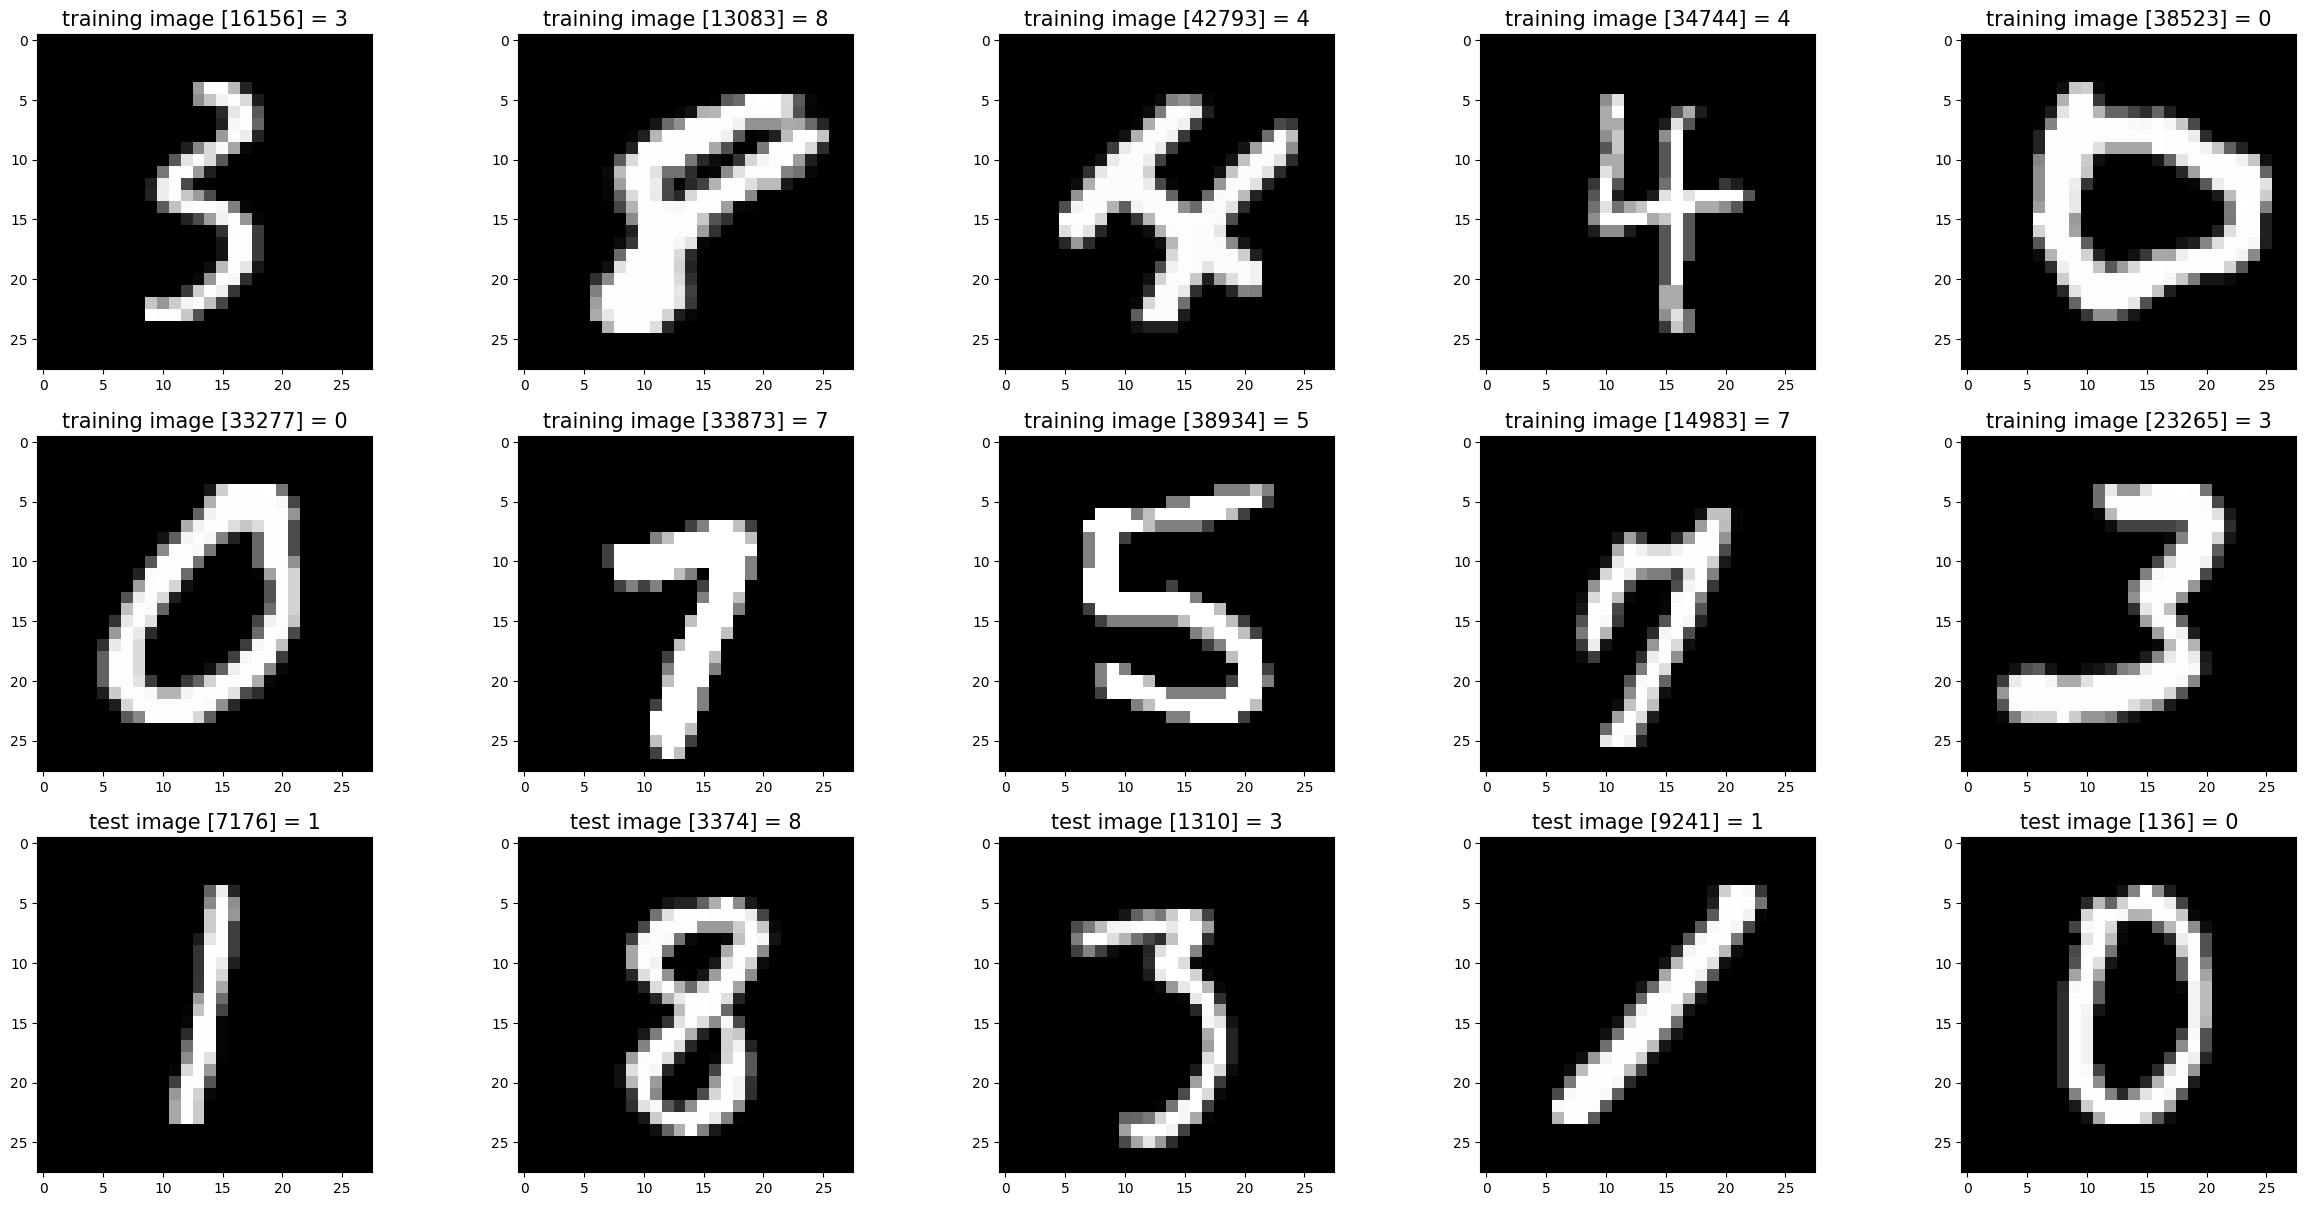

In [3]:

# Verify Reading Dataset via MnistDataloader class
#
%matplotlib inline
import random
import matplotlib.pyplot as plt
import os

print(os.path.abspath(os.getcwd()))
#
# Set file paths based on added MNIST Datasets
#
input_path = 'input'
training_images_filepath = join(input_path, 'train-images-idx3-ubyte/train-images-idx3-ubyte')
training_labels_filepath = join(input_path, 'train-labels-idx1-ubyte/train-labels-idx1-ubyte')
test_images_filepath = join(input_path, 't10k-images-idx3-ubyte/t10k-images-idx3-ubyte')
test_labels_filepath = join(input_path, 't10k-labels-idx1-ubyte/t10k-labels-idx1-ubyte')

#
# Helper function to show a list of images with their relating titles
#
def show_images(images, title_texts):
    cols = 5
    rows = int(len(images)/cols) + 1
    plt.figure(figsize=(30,20))
    index = 1    
    for x in zip(images, title_texts):        
        image = x[0]        
        title_text = x[1]
        plt.subplot(rows, cols, index)        
        plt.imshow(image, cmap=plt.cm.gray)
        if (title_text != ''):
            plt.title(title_text, fontsize = 15);        
        index += 1

#
# Load MINST dataset
#
mnist_dataloader = MnistDataloader(training_images_filepath, training_labels_filepath, test_images_filepath, test_labels_filepath)
(x_train, y_train), (x_test, y_test), (x_val, y_val) = mnist_dataloader.load_data()

#
# Show some random training and test images 
#
images_2_show = []
titles_2_show = []
for i in range(0, 10):
    r = random.randint(1, 50000)
    images_2_show.append(x_train[r])
    titles_2_show.append('training image [' + str(r) + '] = ' + str(y_train[r]))    

for i in range(0, 5):
    r = random.randint(1, 10000)
    images_2_show.append(x_test[r])        
    titles_2_show.append('test image [' + str(r) + '] = ' + str(y_test[r]))    

show_images(images_2_show, titles_2_show)

In [4]:
import tensorflow as tf
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix
from keras.callbacks import EarlyStopping, ModelCheckpoint
print("Tensorflow version: ", tf.__version__)
#tf.debugging.set_log_device_placement(True)

with tf.device('/GPU:0'):
    model = tf.keras.models.Sequential([
        tf.keras.layers.Flatten(input_shape=(28,28)),
        tf.keras.layers.Dense(128, activation='relu'),
        tf.keras.layers.Dropout(0.2),
        tf.keras.layers.Dense(10, activation='softmax')
    ])

#Dataset (from keras dataset) loading and transforming
# mnist = tf.keras.datasets.mnist
# (x_train_pkg, y_train_pkg), (x_test_pkg, y_test_pkg) = mnist.load_data()
# x_train = x_train_pkg
# x_test = x_test_pkg
# y_train = y_train_pkg
# y_test = y_test_pkg
# x_train, x_test = x_train / 255.0, x_test / 255.0

#Dataset from file, loading and transforming
x_train, x_test, x_val = np.array(x_train) / 255.0, np.array(x_test) / 255.0, np.array(x_val) / 255.0
y_train, y_test, y_val = np.array(y_train), np.array(y_test), np.array(y_val)
#print("",x_train[0],"",y_train[0])

predictions = model(x_train[:1]).numpy()
#print("Predictions : \n",predictions)
tf.nn.softmax(predictions).numpy()

loss_fn = tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True)
#print("Loss_fn : \n",loss_fn(y_train[:1], predictions).numpy())
model.compile(
    optimizer = 'adam',
    loss=loss_fn,
    metrics=['accuracy']
)

Tensorflow version:  2.11.0


2023-03-28 11:47:58.046467: I tensorflow/compiler/xla/stream_executor/cuda/cuda_blas.cc:630] TensorFloat-32 will be used for the matrix multiplication. This will only be logged once.


In [5]:
es = EarlyStopping(monitor='accuracy', mode='max', verbose=1, patience=175)
mc = ModelCheckpoint('best_mnist_model.h5', monitor='accuracy', mode='max', verbose=1, save_best_only=True, patience=175)
history = model.fit(x_train, y_train, epochs=20, callbacks=[es,mc])

Epoch 1/20


/home/xmatyas/miniconda3/envs/tf_gpu/lib/python3.9/site-packages/keras/backend.py:5585: UserWarning: "`sparse_categorical_crossentropy` received `from_logits=True`, but the `output` argument was produced by a Softmax activation and thus does not represent logits. Was this intended?
  output, from_logits = _get_logits(
2023-03-28 11:48:00.151021: I tensorflow/compiler/xla/service/service.cc:173] XLA service 0x2c7cfe70 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
2023-03-28 11:48:00.151038: I tensorflow/compiler/xla/service/service.cc:181]   StreamExecutor device (0): NVIDIA GeForce RTX 3060 Ti, Compute Capability 8.6
2023-03-28 11:48:00.154684: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:268] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
2023-03-28 11:48:00.244727: I tensorflow/compiler/jit/xla_compilation_cache.cc:477] Compiled cluster using XLA!  This line is logged at most once fo

1544/1563 [============================>.] - ETA: 0s - loss: 0.3231 - accuracy: 0.9081
Epoch 1: accuracy improved from -inf to 0.90862, saving model to best_mnist_model.h5
1563/1563 [==============================] - 4s 2ms/step - loss: 0.3216 - accuracy: 0.9086
Epoch 2/20
1556/1563 [============================>.] - ETA: 0s - loss: 0.1577 - accuracy: 0.9526
Epoch 2: accuracy improved from 0.90862 to 0.95280, saving model to best_mnist_model.h5
1563/1563 [==============================] - 3s 2ms/step - loss: 0.1574 - accuracy: 0.9528
Epoch 3/20
1554/1563 [============================>.] - ETA: 0s - loss: 0.1159 - accuracy: 0.9651
Epoch 3: accuracy improved from 0.95280 to 0.96504, saving model to best_mnist_model.h5
1563/1563 [==============================] - 3s 2ms/step - loss: 0.1159 - accuracy: 0.9650
Epoch 4/20
1544/1563 [============================>.] - ETA: 0s - loss: 0.0939 - accuracy: 0.9716
Epoch 4: accuracy improved from 0.96504 to 0.97162, saving model to best_mnist_model.

In [6]:
model.evaluate(x_test,  y_test, verbose=2)

probability_model = tf.keras.Sequential([
  model,
  tf.keras.layers.Softmax()
])
probability_model(x_test[:1])

313/313 - 0s - loss: 0.0782 - accuracy: 0.9795 - 389ms/epoch - 1ms/step


<tf.Tensor: shape=(1, 10), dtype=float32, numpy=
array([[0.08533677, 0.08533677, 0.08533677, 0.08533687, 0.08533677,
        0.08533677, 0.08533677, 0.23196898, 0.08533677, 0.0853368 ]],
      dtype=float32)>

[3 8 6 ... 5 6 8]
313/313 [==============================] - 0s 618us/step


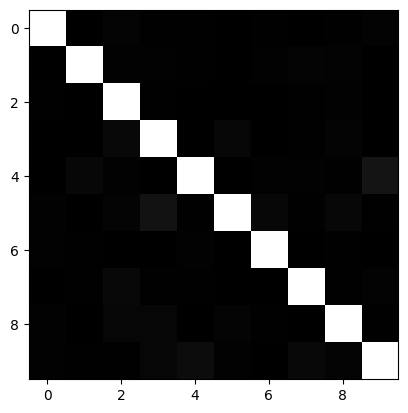

In [7]:
print(y_val)
conf_mat = confusion_matrix(y_true = y_val, y_pred = np.argmax(model.predict(x_val), axis = 1))
plt.imshow(conf_mat, cmap = 'gray', vmin = 0, vmax = 255)
plt.show()


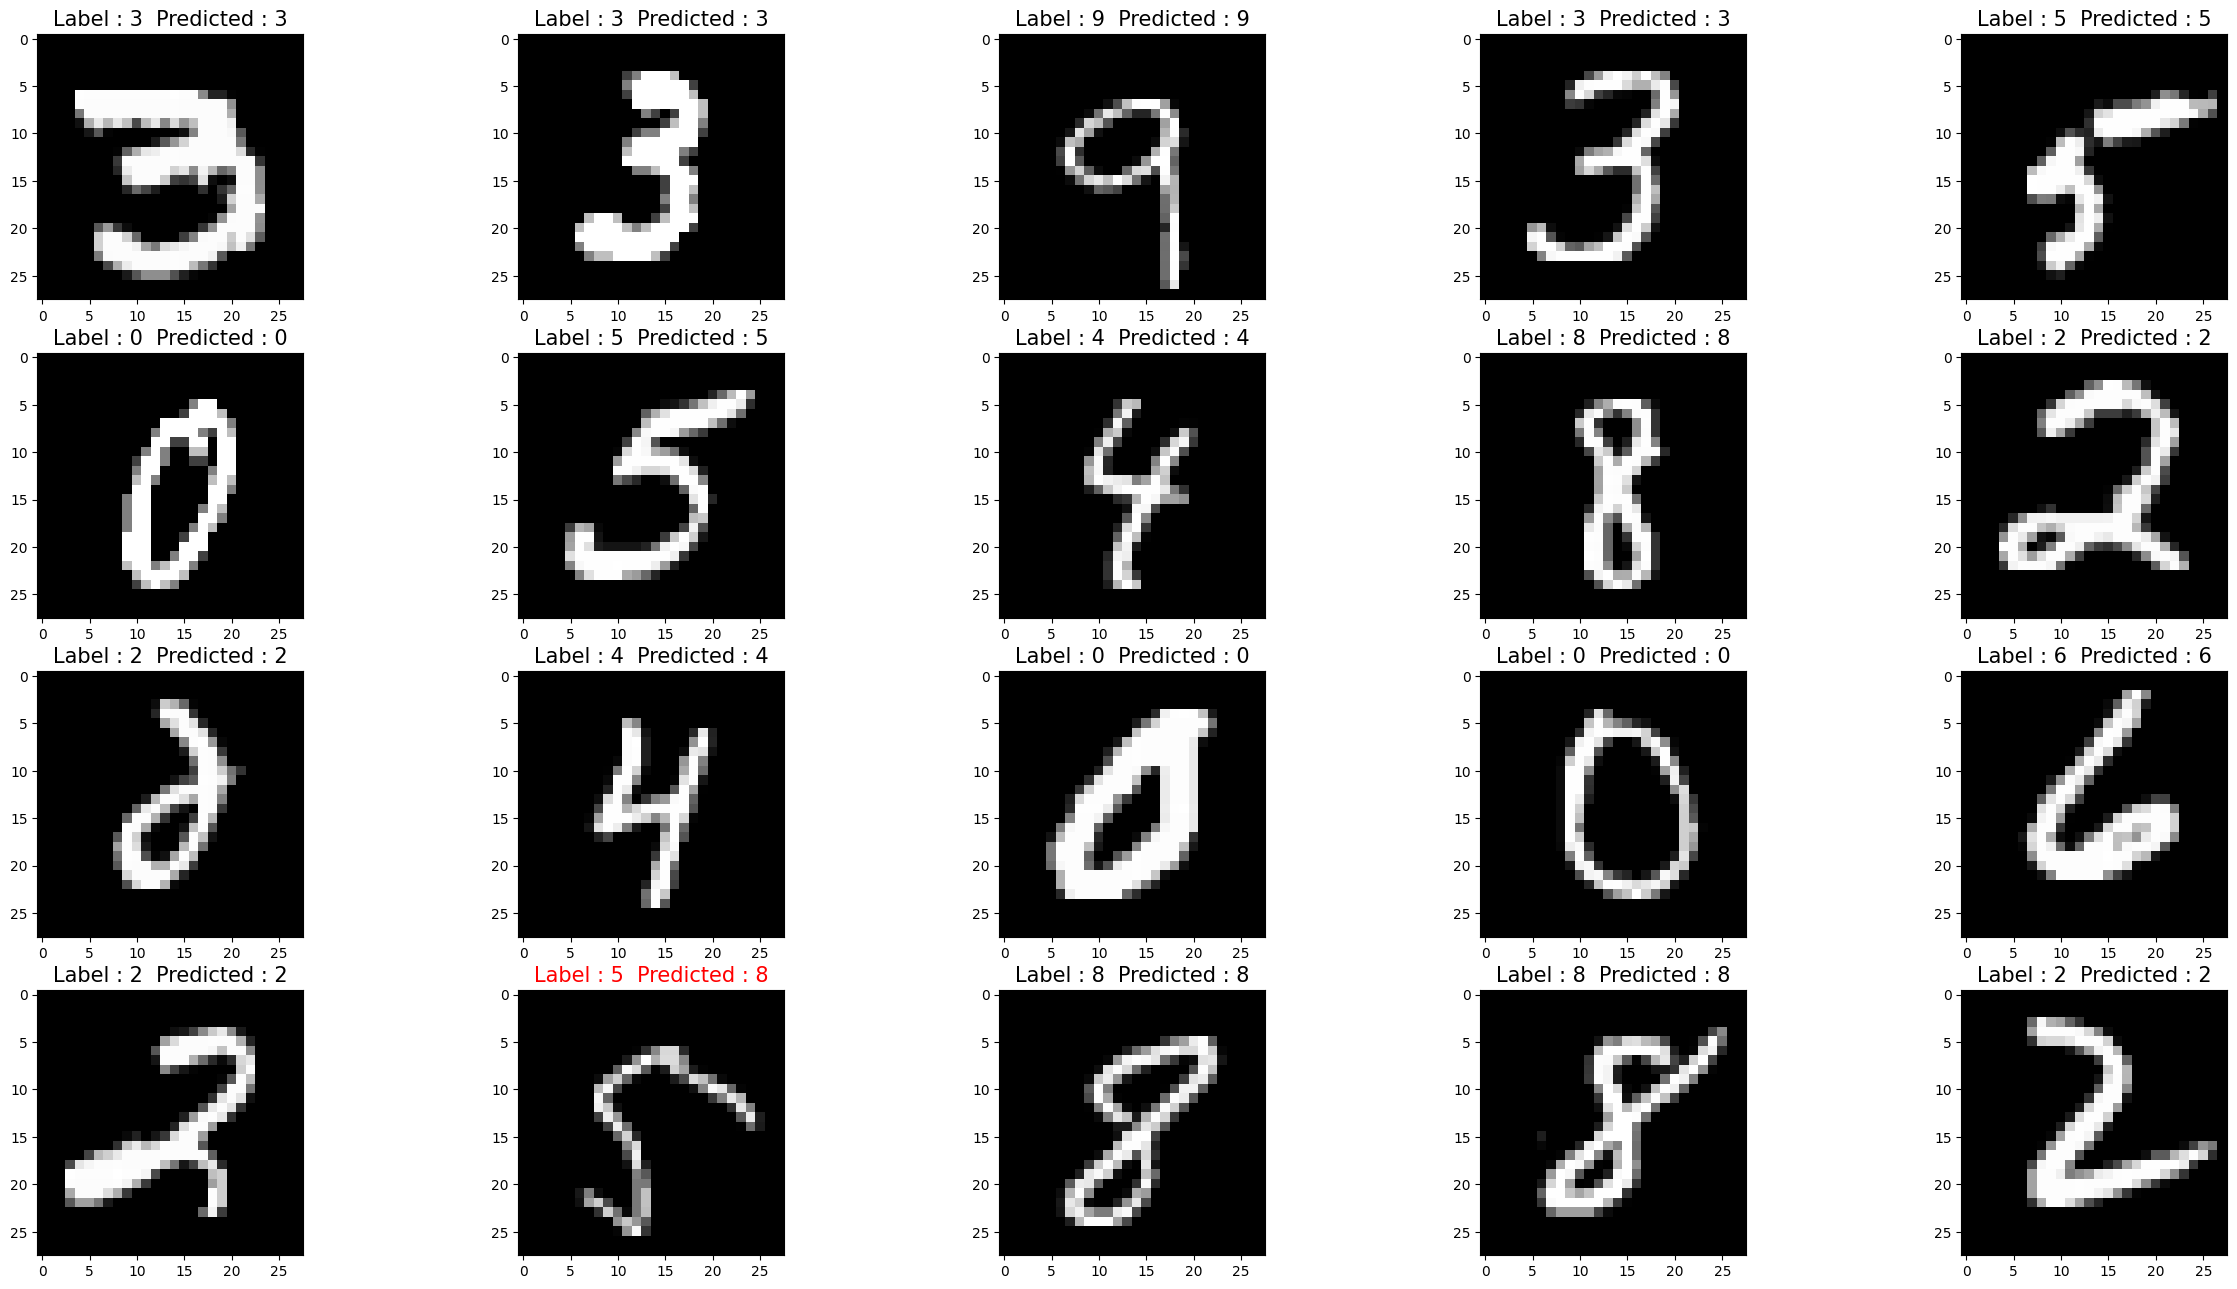

In [8]:
def show_predicted_images(images, title_texts, predicted_labels):
    cols = 5
    rows = int(len(images)/cols) + 1
    plt.figure(figsize=(30,20))
    index = 1    
    for x in zip(images, title_texts, predicted_labels):        
        image = x[0]        
        title_text = x[1]
        predicted_label = x[2]
        plt.subplot(rows, cols, index)        
        plt.imshow(image, cmap=plt.cm.gray)
        if (title_text != ''):
            if (title_text == predicted_label):
                plt.title("Label : " + str(title_text) + "  Predicted : " + str(predicted_label), fontsize = 15);
            else:
                plt.title("Label : " + str(title_text) + "  Predicted : " + str(predicted_label), fontsize = 15, color = 'red');
        index += 1

random_image_index = []
for i in range(0, 20):
    r = random.randint(1, 10000)
    random_image_index.append(r)
if len(random_image_index) > 0:
    random_x_val = np.array([x_val[index] for index in random_image_index])
    random_y_val = np.array([y_val[index] for index in random_image_index])

predicted_labels = model.predict(random_x_val)
predicted_labels = np.argmax(predicted_labels, 1)
show_predicted_images(random_x_val,random_y_val,predicted_labels)